<h1 style="color:magenta;">NSL - Exercises 11 </h1>

### 21/5/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 11.3

### 2D Trigonometric fit

The aim of this exercise is to extend the neural network regression to a two-dimensional space, fitting the following trigonometric function:

$$
f(x,y) = \sin(x^2+y^2)
$$

in the range $x \in [-1.5, 1.5]$ and $y \in [-1.5, 1.5]$.

To handle the 2D nature of the problem, the network structure was adapted by implementing an input layer with 2 neurons, reflecting the coordinate pair $(x, y)$ fed into the system. The hidden architecture mirrors the previous choice, using two layers with 32 and 16 neurons respectively, combined with the `relu` activation function. The output layer consists of a single neuron with a default linear activation to predict the continuous target value $z$.

I tested both the `sgd` and the `adam` optimizers. While both managed to fit the training data remarkably well within the defined interval, `adam` demonstrated a faster and smoother convergence, making it highly efficient at capturing the circular wave pattern of the target function.

The final 3D scatter plot confirms that the network successfully reconstructs the three-dimensional surface.

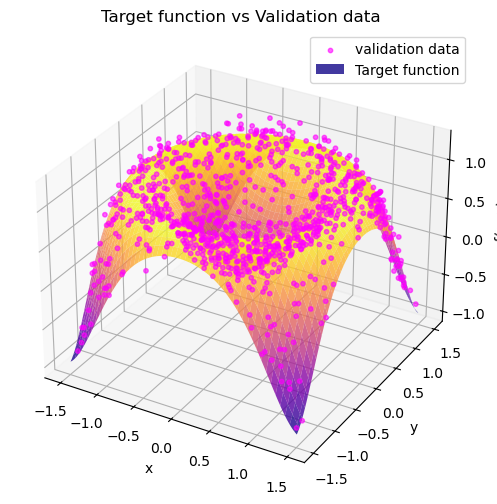

In [26]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(low=-3./2, high=3./2, size=(20000, 2))
x_valid = np.random.uniform(low=-3./2, high=3./2, size=(1000, 2))

y_target = np.sin(x_valid[:, 0]**2 + x_valid[:, 1]**2)

sigma = 0.1 # noise standard deviation
y_train = np.random.normal(np.sin(x_train[:, 0]**2 + x_train[:, 1]**2), scale=sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(np.sin(x_valid[:, 0]**2 + x_valid[:, 1]**2), scale=sigma)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Coords
x = x_valid[:, 0]
y = x_valid[:, 1]
z_target = y_target
z_valid = y_valid

# Plot 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z_valid, color='magenta', label='validation data', alpha=0.6, s=10)

x_grid = np.linspace(min(x), max(x), 100)
y_grid = np.linspace(min(y), max(y), 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.sin(X**2 + Y**2)
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.8, label="Target function")
ax.legend(['Target surface'])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Target function vs Validation data')
ax.legend()
plt.show()

In [27]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(2,)))
#hidden layers
model.add(Dense(32, input_shape=(1,), activation='relu'))
model.add(Dense(16, activation='relu'))
#output layers
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='adam', loss='mse', metrics=['mse'])

# get a summary of our composed model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=30,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1500 - mse: 0.1500 - val_loss: 0.0721 - val_mse: 0.0721
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0424 - mse: 0.0424 - val_loss: 0.0227 - val_mse: 0.0227
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0181 - mse: 0.0181 - val_loss: 0.0143 - val_mse: 0.0143
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0133 - mse: 0.0133 - val_loss: 0.0130 - val_mse: 0.0130
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0121 - mse: 0.0121 - val_loss: 0.0121 - val_mse: 0.0121
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0116 - mse: 0.0116 - val_loss: 0.0114 - val_mse: 0.0114
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0114 - mse: 0.0114 - val_loss: 0.0134 - val_mse: 0.0134
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0113 - mse: 0.0113 - val_loss: 0.0115 - val_mse: 0.0115
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [30]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0113 - mse: 0.0113 

Test loss: 0.01131685171276331
Test accuracy: 0.01131685171276331


In [31]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1647e-04 - mse: 6.1647e-04 

Test loss: 0.0006164650549180806
Test accuracy: 0.0006164650549180806


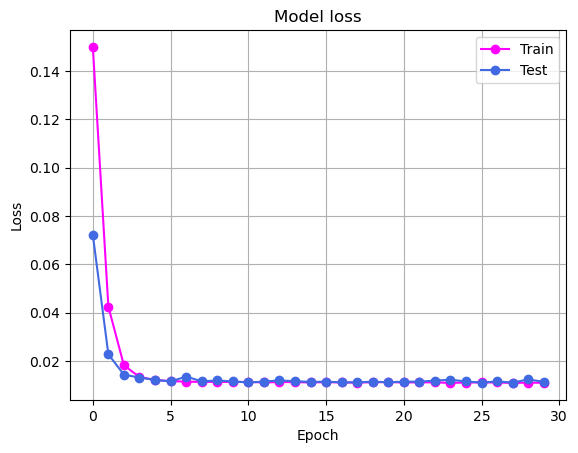

In [32]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'], 'o-', color = 'magenta')
plt.plot(history.history['val_loss'], 'o-', color = 'royalblue')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


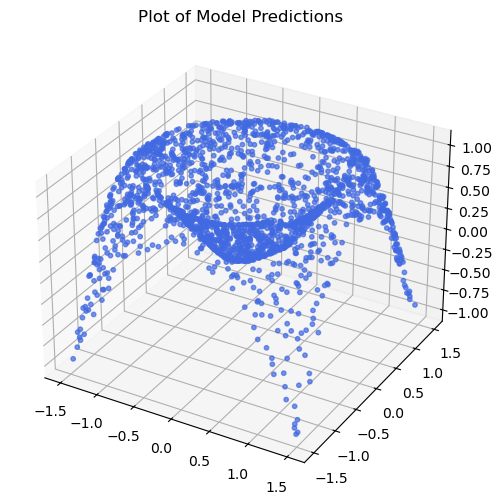

In [33]:
x_predicted = np.random.uniform(-1.5, 1.5,size=(2000, 2))
y_predicted = model.predict(x_predicted)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_predicted[:, 0], x_predicted[:, 1], y_predicted.flatten(), color='royalblue', alpha=0.7, s=10)
plt.title("Plot of Model Predictions")

plt.grid(True)
plt.show()